In [1]:
# Import live code changes in
%load_ext autoreload
%autoreload 

from pathlib import Path
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sovereign.flood import build_basin_curves, BasinLossCurve

In [2]:
# USER CONFIG
adaptation_aep = 0.01 # 100-year flood protection
n_years = 10000 # number of years to simulate
model = 'wri'

#### Set filepaths and provide data info

In [3]:
root = Path.cwd().parent # find project root
risk_basin_path = os.path.join(root, 'outputs', 'flood', 'risk', 'basins', f'risk_basins_m-{model}.csv')
# risk_basin_path = os.path.join(root, 'outputs', 'flood', 'sensitivity', 'basins', 'sd1_low', 'risk_basins.csv') # sensitivity test
copula_path = os.path.join(root, 'outputs', 'flood', 'dependence', 'copulas')
risk_data = pd.read_csv(risk_basin_path)
# Drop first "unnamed column"
risk_data = risk_data.iloc[:, 1:]
# Add AEP column
risk_data['AEP'] = 1 / risk_data['RP']
# Add a column converting current prorection level into AEP
risk_data['Pr_L_AEP'] = np.where(risk_data['Pr_L'] == 0, 0, 1 / risk_data['Pr_L']) # using numpy where avoids zero division errors
risk_data.reset_index(drop=True, inplace=True)

#### Run a simulation

In [4]:
# Build basin loss probability curves
basin_curves: dict[int, BasinLossCurve] = build_basin_curves(risk_data)

In [5]:
# Prepare simulation
all_sectors = {comp.sector for curve in basin_curves.values() for comp in curve.components} # Find all sectors
sector_baseline_losses = {s: np.zeros(n_years) for s in all_sectors}
sector_adapted_losses = {s: np.zeros(n_years) for s in all_sectors}
gva_sectors = ["Agriculture", "Manufacturing", "Service"]
cap_sectors = ["Public", "Private"]
basin_ids = list(basin_curves.keys())
# Load precomputed copula basin dependence simulations
# c_random_numbers = pd.read_parquet(os.path.join(copula_path, "t_random_numbers.parquet.gzip"))
c_random_numbers = pd.read_parquet(os.path.join(copula_path, "copula_random_numbers.gzip"))
c_random_numbers.columns = (pd.Index(c_random_numbers.columns).astype(str).str.strip().astype(int)) # clean columns
# # Load independent random numbers
# basin_ids = list(basin_curves.keys())
# c_random_numbers = pd.DataFrame(
#     np.random.random(size=(n_years, len(basin_ids))),
#     columns=basin_ids
# )

In [6]:
# Run a simulation with copula dependence between basins
for t in tqdm(range(n_years)):
    sector_year_baseline = {s: 0.0 for s in all_sectors}
    sector_year_adapted  = {s: 0.0 for s in all_sectors}

    random_ns = c_random_numbers.loc[t]  # Series indexed by basin IDs (columns)

    for basin_id in basin_ids:
        key = int(basin_id)
        if key not in random_ns.index:
            continue

        curve = basin_curves[key]
        u = random_ns.loc[key]            # label-based access (safe)
        aep_event = 1.0 - float(u)

        for s in all_sectors:
            sector_year_baseline[s] += curve.loss_at_event_aep(aep_event, sector=s)
            sector_year_adapted[s]  += curve.loss_at_event_aep(
                aep_event,
                scenario="adaptation",
                adapted_protection_aep=adaptation_aep,
                sector=s,
            )

    for s in all_sectors:
        sector_baseline_losses[s][t] = sector_year_baseline[s]
        sector_adapted_losses[s][t]  = sector_year_adapted[s]

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [01:11<00:00, 139.92it/s]


#### Inspect Results

In [7]:
# Store Results
# GVA losses (sum of GVA sectors)
gva_baseline_losses = sum(sector_baseline_losses[s] for s in gva_sectors)
gva_adapted_losses  = sum(sector_adapted_losses[s]  for s in gva_sectors)

# Capital stock losses (sum of capital sectors)
cap_baseline_losses = sum(sector_baseline_losses[s] for s in cap_sectors)
cap_adapted_losses  = sum(sector_adapted_losses[s]  for s in cap_sectors)

# Store in dataframe
baseline_losses_df = pd.DataFrame({
    "year_index": np.arange(n_years),
    "GVA_loss": gva_baseline_losses,
    "CAP_dam": cap_baseline_losses,
    "AGR_loss": sector_baseline_losses["Agriculture"],
    "MAN_loss": sector_baseline_losses["Manufacturing"],
    "SER_loss": sector_baseline_losses["Service"],
    "PUB_dam": sector_baseline_losses["Public"],
    "PRI_dam": sector_baseline_losses["Private"]
})

# Store in dataframe
adapted_losses_df = pd.DataFrame({
    "year_index": np.arange(n_years),
    "GVA_loss": gva_adapted_losses,
    "CAP_dam": cap_adapted_losses,
    "AGR_loss": sector_adapted_losses["Agriculture"],
    "MAN_loss": sector_adapted_losses["Manufacturing"],
    "SER_loss": sector_adapted_losses["Service"],
    "PUB_dam": sector_adapted_losses["Public"],
    "PRI_dam": sector_adapted_losses["Private"]
})

print("GVA AAL baseline:", gva_baseline_losses.mean())
print("GVA AAL adapted :", gva_adapted_losses.mean())
print("Cap AAL baseline:", cap_baseline_losses.mean())
print("Cap AAL adapted :", cap_adapted_losses.mean())

print("GVA AAL avoided :", gva_baseline_losses.mean() - gva_adapted_losses.mean())
print("Cap AAL avoided :", cap_baseline_losses.mean() - cap_adapted_losses.mean())

GVA AAL baseline: 33204866.068507213
GVA AAL adapted : 22443420.260011103
Cap AAL baseline: 39000898.845612526
Cap AAL adapted : 24310785.687216442
GVA AAL avoided : 10761445.80849611
Cap AAL avoided : 14690113.158396084


In [8]:
# Pull sector quantile loss
sector = "CAP_dam"
quantile = 0.99
baseline_loss = baseline_losses_df[sector].quantile(quantile)
adapted_loss = adapted_losses_df[sector].quantile(quantile)
print(f'Baseline p:{quantile} loss: {baseline_loss}')
print(f'Adapted p:{quantile} loss: {adapted_loss}')

Baseline p:0.99 loss: 523106682.68394303
Adapted p:0.99 loss: 349856106.6663493


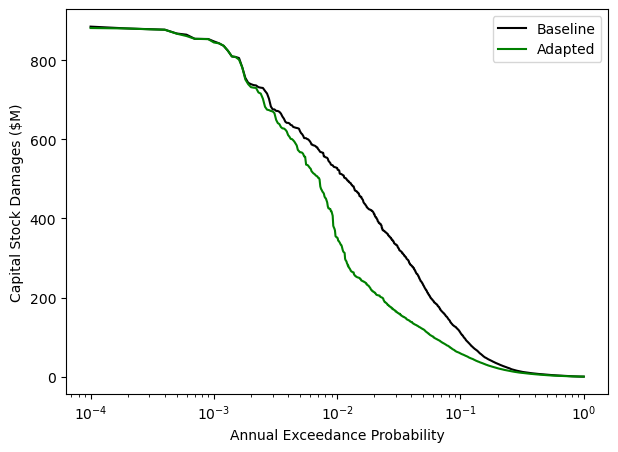

In [19]:
# E-P plot
sector = "CAP_dam"
baseline_losses_sorted = np.sort(baseline_losses_df[sector])[::-1] / 1e6
adapted_losses_sorted = np.sort(adapted_losses_df[sector])[::-1] / 1e6
N = len(baseline_losses_df[sector])
exceedance_prob = np.arange(1, N+1) / (N + 1)
plt.figure(figsize=(7,5))
plt.plot(exceedance_prob, baseline_losses_sorted, label='Baseline', color='k')
plt.plot(exceedance_prob, adapted_losses_sorted, label='Adapted', color='g')
plt.legend()
plt.ylabel('Capital Stock Damages ($M)')
plt.xlabel('Annual Exceedance Probability')
plt.xscale("log")   # optional but standard in catastrophe modelling
plt.yscale("linear")


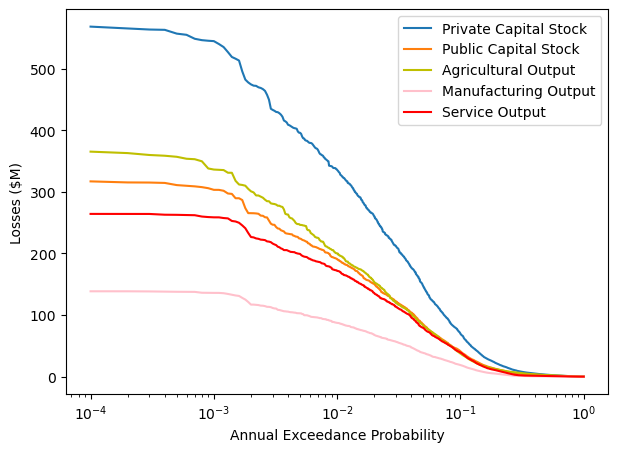

In [22]:
# E-P plot (sectoral breakdown)
N = len(baseline_losses_df['CAP_dam'])
exceedance_prob = np.arange(1, N+1) / (N + 1)
plt.figure(figsize=(7,5))
plt.plot(exceedance_prob, np.sort(baseline_losses_df['PRI_dam'])[::-1] / 1e6, label='Private Capital Stock')
plt.plot(exceedance_prob, np.sort(baseline_losses_df['PUB_dam'])[::-1] / 1e6, label='Public Capital Stock')
plt.plot(exceedance_prob, np.sort(baseline_losses_df['AGR_loss'])[::-1] / 1e6, label='Agricultural Output', color='y')
plt.plot(exceedance_prob, np.sort(baseline_losses_df['MAN_loss'])[::-1] / 1e6, label='Manufacturing Output', color='pink')
plt.plot(exceedance_prob, np.sort(baseline_losses_df['SER_loss'])[::-1] / 1e6, label='Service Output', color='red')
plt.legend()
plt.ylabel('Losses ($M)')
plt.xlabel('Annual Exceedance Probability')
plt.xscale("log")   # optional but standard in catastrophe modelling
plt.yscale("linear")

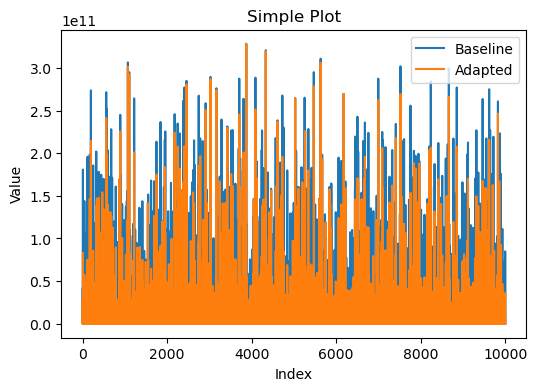

In [17]:
# Simple Simulation Series Plot
plt.figure(figsize=(6,4))
plt.plot(baseline_losses_df['CAP_dam'], label='Baseline')
plt.plot(adapted_losses_df['CAP_dam'], label='Adapted')
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Simple Plot")
plt.show()

### Scratch

In [41]:
# Independent simulation
rng = np.random.default_rng(seed=42)  # for reproducibility
# Run a simulation with independence between basins
for t in tqdm(range(n_years)):
    sector_year_baseline = {s: 0.0 for s in all_sectors}
    sector_year_adapted = {s: 0.0 for s in all_sectors}

    for basin_id in basin_ids:
        curve = basin_curves[basin_id]

        # draw an independent U(0,1) for this basin-year
        u = rng.random()
        aep_event = 1.0 - u   # or aep_event = u, depending on how your curve is defined

        for s in all_sectors:
            bl = curve.loss_at_event_aep(aep_event, sector=s)
            ad = curve.loss_at_event_aep(
                aep_event,
                scenario="adaptation",
                adapted_protection_aep=adaptation_aep,
                sector=s,
            )
            sector_year_baseline[s] += bl
            sector_year_adapted[s] += ad

    for s in all_sectors:
        sector_baseline_losses[s][t] = sector_year_baseline[s]
        sector_adapted_losses[s][t] = sector_year_adapted[s]

100%|███████████████████████████████████████████████████████████████████████████| 50000/50000 [04:20<00:00, 192.28it/s]


In [42]:
# Store Results
# GVA losses (sum of GVA sectors)
gva_baseline_losses = sum(sector_baseline_losses[s] for s in gva_sectors)
gva_adapted_losses  = sum(sector_adapted_losses[s]  for s in gva_sectors)

# Capital stock losses (sum of capital sectors)
cap_baseline_losses = sum(sector_baseline_losses[s] for s in cap_sectors)
cap_adapted_losses  = sum(sector_adapted_losses[s]  for s in cap_sectors)

# Store in dataframe
baseline_losses_df = pd.DataFrame({
    "year_index": np.arange(n_years),
    "GVA_loss": gva_baseline_losses,
    "CAP_dam": cap_baseline_losses,
    "AGR_loss": sector_baseline_losses["Agriculture"],
    "MAN_loss": sector_baseline_losses["Manufacturing"],
    "SER_loss": sector_baseline_losses["Service"],
    "PUB_dam": sector_baseline_losses["Public"],
    "PRI_dam": sector_baseline_losses["Private"]
})

# Store in dataframe
adapted_losses_df = pd.DataFrame({
    "year_index": np.arange(n_years),
    "GVA_loss": gva_adapted_losses,
    "CAP_dam": cap_adapted_losses,
    "AGR_loss": sector_adapted_losses["Agriculture"],
    "MAN_loss": sector_adapted_losses["Manufacturing"],
    "SER_loss": sector_adapted_losses["Service"],
    "PUB_dam": sector_adapted_losses["Public"],
    "PRI_dam": sector_adapted_losses["Private"]
})

print("GVA AAL baseline:", gva_baseline_losses.mean())
print("GVA AAL adapted :", gva_adapted_losses.mean())
print("Cap AAL baseline:", cap_baseline_losses.mean())
print("Cap AAL adapted :", cap_adapted_losses.mean())

print("GVA AAL avoided :", gva_baseline_losses.mean() - gva_adapted_losses.mean())
print("Cap AAL avoided :", cap_baseline_losses.mean() - cap_adapted_losses.mean())

GVA AAL baseline: 4251404599.4592586
GVA AAL adapted : 2474283409.2611217
Cap AAL baseline: 12539787504.079584
Cap AAL adapted : 7568790472.048731
GVA AAL avoided : 1777121190.1981368
Cap AAL avoided : 4970997032.030853


In [50]:
# Pull sector quantile loss
sector = "CAP_dam"
quantile = 0.9998
baseline_loss = baseline_losses_df[sector].quantile(quantile)
adapted_loss = adapted_losses_df[sector].quantile(quantile)
print(f'Baseline p:{quantile} loss: {baseline_loss}')
print(f'Adapted p:{quantile} loss: {adapted_loss}')

Baseline p:0.9998 loss: 122160496365.34007
Adapted p:0.9998 loss: 113086728272.2765


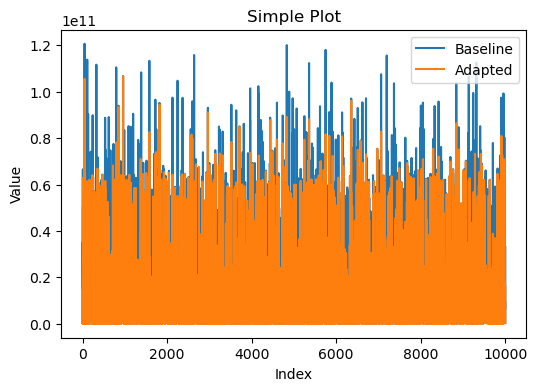

In [13]:
# Simple Simulation Series Plot
plt.figure(figsize=(6,4))
plt.plot(baseline_losses_df['CAP_dam'], label='Baseline')
plt.plot(adapted_losses_df['CAP_dam'], label='Adapted')
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Simple Plot")
plt.show()

#### Plot EVENTS (copula check)

In [21]:
## Functions and colourcoding for plots
# Return period bins (inclusive of lower bound)
rp_bins = [0, 2, 5, 10, 20, 50, 100, 200, 500, 10_000]  # last one catches >500

# Colours:
# First: grey for 0–2
# Then: 8 steps of viridis
viridis = plt.cm.viridis(np.linspace(0.2, 1, len(rp_bins) - 2))
colors = ["lightgrey"] + list(viridis)

rp_cmap = ListedColormap(colors)
rp_norm = BoundaryNorm(rp_bins, rp_cmap.N)

def plot_rp_classes(sim_year, aep_df, basins_gdf,
                    basin_id_field="HYBAS_ID_str",
                   reverse=False):
    """
    Discrete return-period class map for a given simulation year.
    """

    # ---- Select AEP row ----
    if isinstance(sim_year, int):
        row = aep_df.iloc[sim_year]
        label = f"simulation year {sim_year}"
    else:
        row = aep_df.loc[sim_year]
        label = f"year {sim_year}"

    # ---- Format AEP as a long table ----
    df = row.rename("aep").reset_index()
    df.columns = [basin_id_field, "aep"]

    if reverse == True:
        df['aep'] = 1 - df['aep']

    # ---- Join onto basins ----
    gdf = basins_gdf.merge(df, on=basin_id_field, how="left")

    # Compute return period safely
    gdf["rp"] = np.where(gdf["aep"] > 0, 1.0 / gdf["aep"], np.nan)

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(8, 8))

    gdf.plot(
        column="rp",
        cmap=rp_cmap,
        norm=rp_norm,
        legend=True,
        edgecolor="black",
        linewidth=0.1,
        ax=ax,
    )

    ax.set_title(f"Basin Return Period – {label}")
    ax.set_axis_off()
    plt.tight_layout()

    return fig, ax


In [22]:
# Load data
l6_basins_path = os.path.join(root, 'inputs', 'boundaries', 'basins', 'BA_THA_lev06.shp')
# Copula random numbers
aep_df = c_random_numbers.copy()
aep_df.columns = aep_df.columns.astype(str)
basin_cols = aep_df.columns
# Independent random #s
indep_df = pd.DataFrame(np.random.rand(1000, len(basin_cols)), columns=basin_cols)
l6_basins = gpd.read_file(l6_basins_path)
l6_basins['HYBAS_ID_str'] = l6_basins['HYBAS_ID'].astype(str)

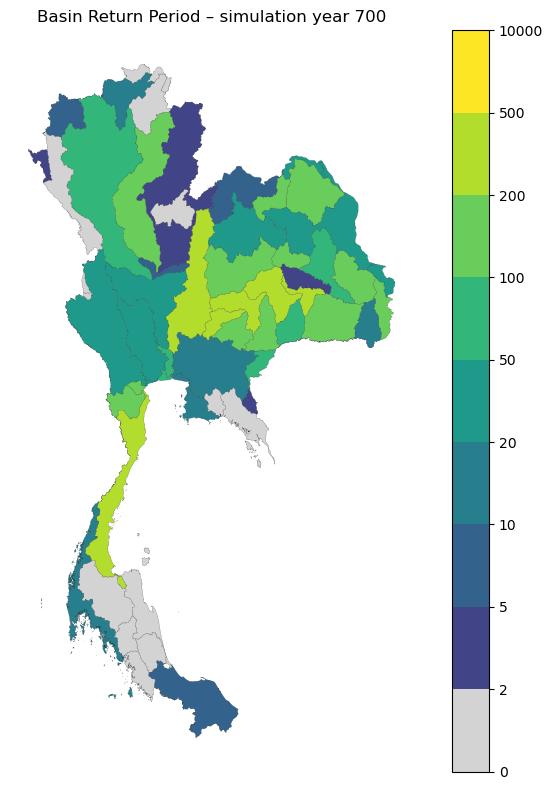

In [44]:
sim_n = 700
fig, ax = plot_rp_classes(sim_n, aep_df, l6_basins, reverse=True)